In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load the data
df = pd.read_csv('noisy_curvefit_data.csv')

# Display the first few rows to make sure it loaded correctly
df.head()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [4]:
# Check the shape (rows, columns)
print(f"Shape: {df.shape}")

# Specific row and column counts
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")

# Print first five rows
print("\nFirst five rows:")
print(df.head())

# Print last five rows
print("\nLast five rows:")
print(df.tail())

# Get column names
print("\nColumn names:")

Shape: (100, 6)
Rows: 100
Columns: 6

First five rows:
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113

Last five rows:
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850

Column names:


['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']


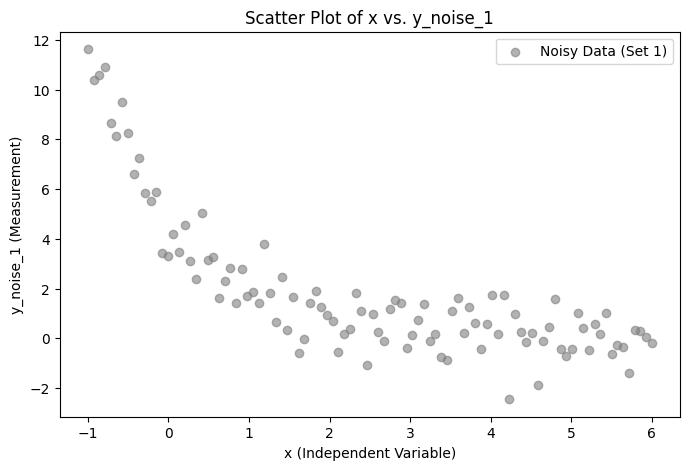

In [6]:
print(df.columns.tolist())
plt.figure(figsize=(8, 5))

# Plot the data as gray dots
plt.scatter(df['x'], df['y_noise_1'], color='gray', alpha=0.6, label='Noisy Data (Set 1)')

# Add labels and title
plt.xlabel('x (Independent Variable)')
plt.ylabel('y_noise_1 (Measurement)')
plt.title('Scatter Plot of x vs. y_noise_1')

# Add legend
plt.legend()

# Show the plot
plt.show()

Fit: y = 4.71 * e^(-0.92 * x)


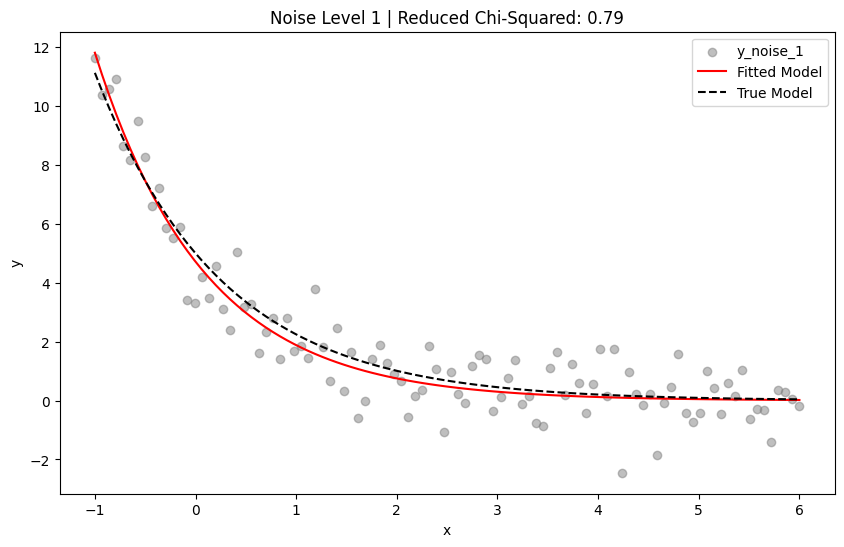

In [7]:
# 1. Define the model
def model(x, A, k):
    return A * np.exp(-k * x)

# 2. Fit the model to y_noise_1
# We need to grab the actual columns from our dataframe 'df'
x_data = df['x']
y_data = df['y_noise_1']
p0 = [1, 1]

popt, pcov = curve_fit(model, x_data, y_data, p0=p0)

# 3. Extract best-fit parameters
A_fit, k_fit = popt

# 4. Print the fitted model
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

# 5. Calculate reduced chi-squared
residuals = y_data - model(x_data, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x_data) - len(popt)
chi2_reduced = chi2 / dof

# 6. Plot the result
plt.figure(figsize=(10, 6))

# Scatter: noisy data
plt.scatter(x_data, y_data, color='gray', alpha=0.5, label='y_noise_1')

# Red line: fitted model
plt.plot(x_data, model(x_data, A_fit, k_fit), color='red', label='Fitted Model')

# Black dotted line: true model (A=5, k=0.8)
plt.plot(x_data, model(x_data, 5, 0.8), color='black', linestyle='--', label='True Model')

# Title and labels
plt.title(f"Noise Level 1 | Reduced Chi-Squared: {chi2_reduced:.2f}")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

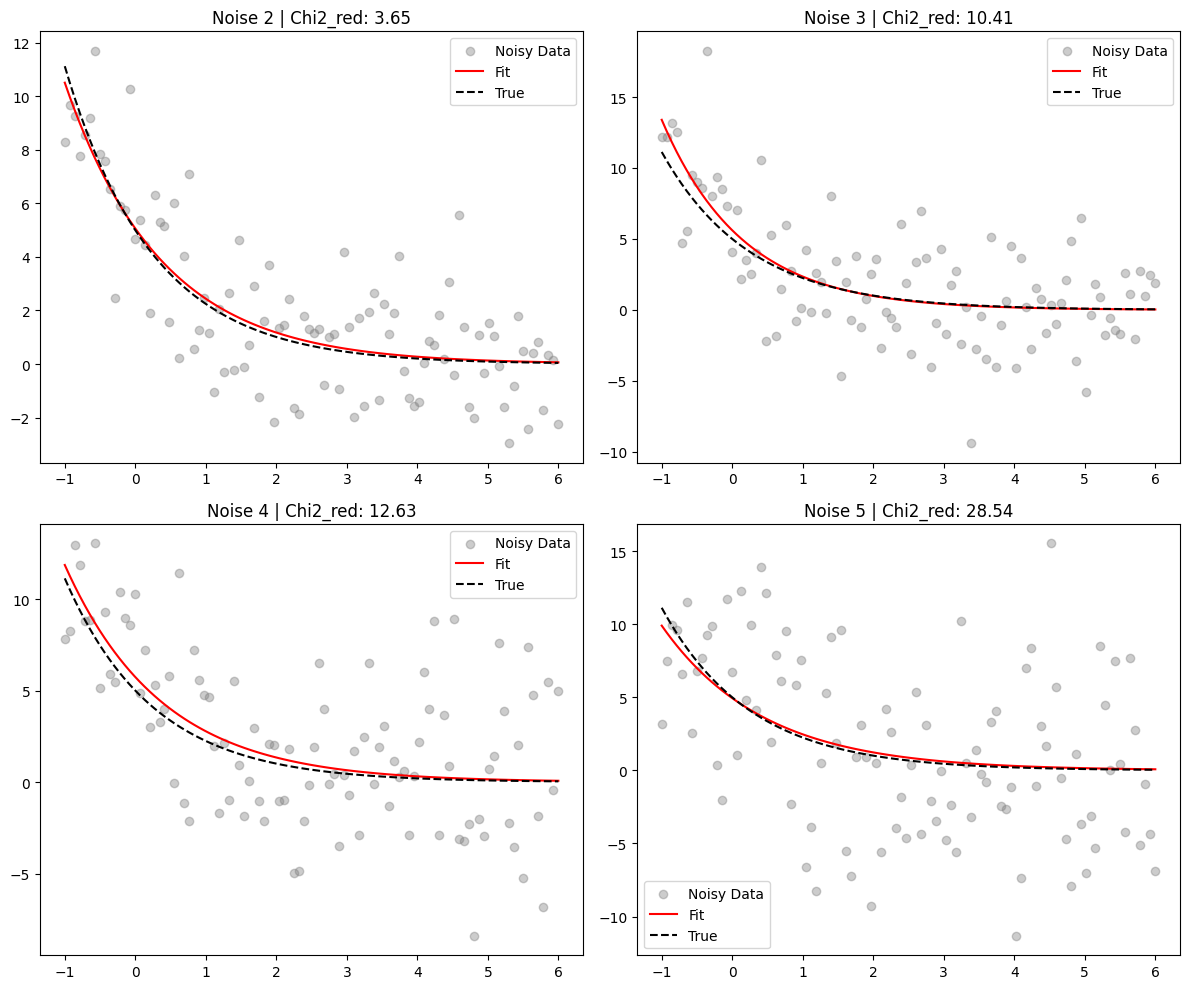

In [8]:
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    
    # Calculate reduced chi-squared
    residuals = y - model(x, *popt)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    
    return popt, chi2_reduced

# Prepare to loop
noise_cols = ['y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Makes it easier to loop through a grid

# Store results for the final step
results_list = []

# First, add the data from noise_1 (which we did manually before) to our results list
popt1, chi1 = fit_model(df['x'], df['y_noise_1'])
results_list.append([1, popt1[0], popt1[1], chi1])

# 3. Loop through the remaining noise levels
for i, col in enumerate(noise_cols):
    ax = axes[i]
    x_val = df['x']
    y_val = df[col]
    
    popt, red_chi = fit_model(x_val, y_val)
    results_list.append([i+2, popt[0], popt[1], red_chi]) # i+2 because loop starts at noise_2
    
    # Plotting
    ax.scatter(x_val, y_val, color='gray', alpha=0.4, label='Noisy Data')
    ax.plot(x_val, model(x_val, *popt), color='red', label='Fit')
    ax.plot(x_val, model(x_val, 5, 0.8), color='black', linestyle='--', label='True')
    
    ax.set_title(f"Noise {i+2} | Chi2_red: {red_chi:.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

#Q1: As noise increases, the red line will likely wiggle further away from the black dotted line. This is because the random "noise" pulls the curve-fitting algorithm away from the true underlying trend.
#Q2: It should increase significantly as noise increases. Why? Because the "residuals" (the distance between the dots and the line) get much larger, and the model can no longer explain that variation.

In [ ]:
results_df = pd.DataFrame(results_list, columns=['Noise level', 'A_fit', 'k_fit', 'Reduced chi-squared'])

# 2. Save to CSV
results_df.to_csv("noisy_parameters.csv", index=False)

print("File saved! Here is a preview:")
print(results_df)

In [10]:
# 1. Create the results DataFrame (RUN THIS CELL)
results_df = pd.DataFrame(results_list, columns=['Noise level', 'A_fit', 'k_fit', 'Reduced chi-squared'])

# 2. Save to CSV
results_df.to_csv("noisy_parameters.csv", index=False)